In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from resources.lattices import connectivity

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_add_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx

import optuna 
import networkx as nx

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import GCN, GAT

# GNN Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [5]:
DAT = DATA(load=True, model="GNN")

In [6]:
DAT.train_in.shape, DAT.train_out.shape

((3588, 357, 2), (3588, 201))

In [7]:
perIN_ = DAT.perIN.reshape(int(len(DAT.perIN)/2), 2)
perIN_ = np.array([i for i in perIN_ if max(perIN_[:,0]) != i[0] and min(perIN_[:,0]) != i[0] and 
                                        max(perIN_[:,1]) != i[1] and min(perIN_[:,1]) != i[1]])
elems = connectivity("FCC", perIN_/1000, [10/1000]*20)

edges = elems[:, 1:] - 1
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [33]:
in_size = DAT.train_in.shape[-1]
out_size = DAT.train_out.shape[-1]
h_size = [8, 32, 128]

BATCH_SIZE = 128
LEARNING_RATE = 1e-3
n_epochs = 500

In [34]:
trainDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.train_in[:1000], DAT.train_outST[:1000])]
valDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.val_in, DAT.val_outST)]
testDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.test_in, DAT.test_outST)]

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

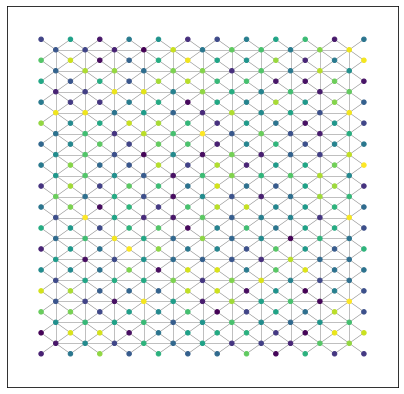

In [35]:
visualize_graphNetwork(train_dataloader, pos=perIN_, colors=None, layout="kk")

In [36]:
gcn1 = GCN(in_size, h_size, out_size, norm="batch", pool="mean").to(device)
gat1 = GAT(in_size, h_size, out_size, heads=1, norm="batch", pool="mean").to(device)
model = gat1

opt = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=25, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.7, patience=8, threshold=1e-3, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [37]:
gat1, epoch, train_lossLog, val_lossLog = train_model('gnn', model, lossf, n_epochs, opt, train_dataloader, 
                                                      val_dataloader=val_dataloader, scheduler=ReduceLR, 
                                                      earlyStop=earlyStop, verbose=10)

Epoch: 1 - Loss: 0.36306747794151306
Epoch: 10 - Loss: 0.2325589507818222
Epoch: 20 - Loss: 0.13758613169193268
Epoch: 30 - Loss: 0.07812947034835815
Epoch: 40 - Loss: 0.04444114863872528
Epoch: 50 - Loss: 0.025517530739307404
Epoch: 60 - Loss: 0.016213152557611465
Epoch: 70 - Loss: 0.01066501997411251
Epoch: 80 - Loss: 0.00850155483931303
Epoch: 90 - Loss: 0.006758862175047398
Epoch: 100 - Loss: 0.007017436902970076
Epoch: 110 - Loss: 0.006074969191104174
Epoch: 120 - Loss: 0.005987436510622501
Epoch: 130 - Loss: 0.005353103391826153
Epoch: 140 - Loss: 0.005593286827206612
Epoch: 150 - Loss: 0.006316113751381636
Epoch: 160 - Loss: 0.005466922651976347
Epoch: 170 - Loss: 0.005054601933807135
Epoch: 180 - Loss: 0.005447570700198412
Epoch: 190 - Loss: 0.00502342265099287
Epoch: 200 - Loss: 0.00536099448800087
Epoch: 210 - Loss: 0.004824500065296888
Epoch: 220 - Loss: 0.005352456122636795
Epoch: 230 - Loss: 0.004547783173620701
Epoch: 240 - Loss: 0.004632836207747459
Epoch: 250 - Loss: 0.

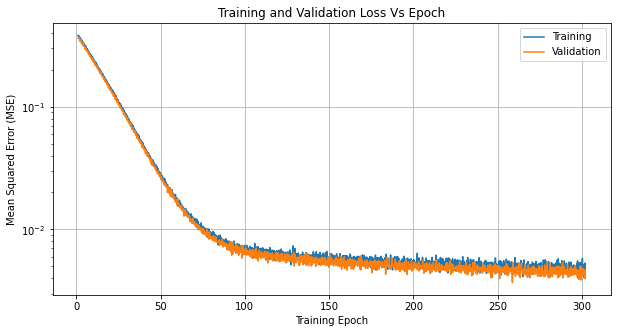

In [38]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [40]:
test_outputs = predict_model("gnn", model, test_dataloader)
test_outputs = standardize(test_outputs, DAT.outParams[0], DAT.outParams[1], mode=1)

AttributeError: 'GlobalStorage' object has no attribute 'float'

In [15]:
err = list(sum(abs(DAT.test_out - test_outputs)))
err.index(min(err)), err.index(max(err))

(31, 90)

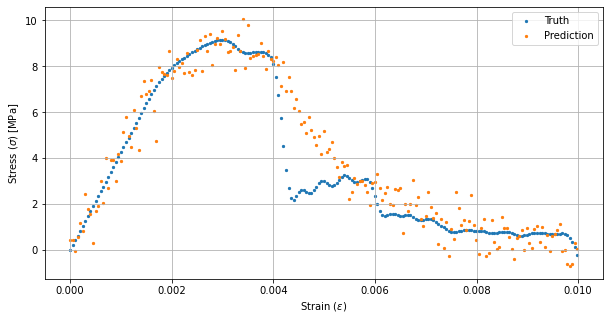

In [16]:
plot_StressStrainOUT(DAT.perOUT, DAT.train_out, test_outputs, indx=93)